In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

 - https://stackoverflow.com/questions/79529333/phase-portrait-of-coupled-odes-not-matching-expected-graph-in-python-scipy
 - https://pmc.ncbi.nlm.nih.gov/articles/PMC10335700/pdf/pcbi.1011269.pdf

In [2]:
N = 4.
rd = 0.6
epsilon = 6.
alpha = 1.5
beta = 3.5
theta = 0.5
a = 0.1
delta = - np.pi / 3.

In [3]:
p0 = (N, a, rd, alpha, beta, theta, delta, epsilon)

In [4]:
def coupling(t, a, delta):
    return 1. - 0.5 * np.sin(a * t + delta)

In [5]:
def system(t, y, N, a, rd, alpha, beta, theta, delta, epsilon):
    x, r = y
    w = coupling(t, a, delta)
    term = np.power((w * x - x + 1.), N - 1.)
    denom = (N * (w - 1.))
    return np.array([
        x * (1. -x) * (r * (w * term -1.) / denom - 1. - rd * (term -1.) / denom),
        epsilon * (r - alpha) * (beta - r) * ((- x) * (r * (w * term -1.) / denom -1.) + rd * theta * (1. -x) * (term - 1.) / denom)
    ])

In [6]:
t = np.linspace(0., 100., 500)

In [7]:
x0s = np.linspace(0.00, 1.00, 20)
r0s = np.linspace(1.50, 3.50, 20)

In [8]:
solutions = []
for x0 in x0s:
    for r0 in r0s:
        solution = integrate.solve_ivp(system, [t.min(), t.max()], [x0, r0], args=p0, t_eval=t, rtol=1e-9, atol=1e-12)
        solutions.append(solution)

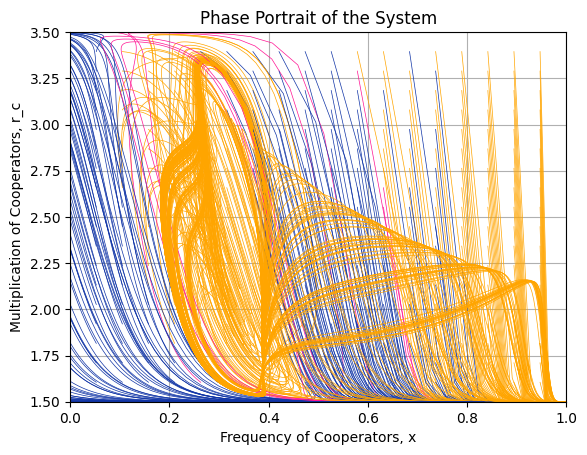

In [9]:
fig, axe = plt.subplots()
for sol in solutions:
    x_traj, rc_traj = sol.y
    final_x, final_rc = x_traj[-1], rc_traj[-1]

    if final_x < 0.001:  # Extinct cooperators
        color = '#1034a6'
    elif final_x > 0.80 and abs(final_rc - alpha) < 0.3 :  # Full cooperation
        color = '#ff1493'
    else:  # Cyclic behavior
        color = 'orange'
        
    #color = "teal"

    axe.plot(x_traj, rc_traj, color=color, linewidth=0.5)

axe.set_xlabel("Frequency of Cooperators, x")
axe.set_ylabel("Multiplication of Cooperators, r_c")
axe.set_title("Phase Portrait of the System")
axe.set_xlim([0.0, 1.0])
axe.set_ylim([1.5, 3.5])
axe.grid()